# **UTS Analitik Visualisasi Data Coffee Sales**☕



|     Keterangan           | Isi                       |
|--------------------------|----------------------------|
| ⭐ Nama                  | Claudya Yusfa Ariyani      |
| ⭐ NIM                   | 2509116043                 |
| ⭐ Kelas                 | B                          |
| ⭐ Dosen Pengampu        | Dr. Akhmad Irsyad, S.T., M.Kom. |

# **Import Library**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Memuat Dataset**

In [2]:
file = '/content/Coffe_sales.csv'
df = pd.read_csv(file)
df

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000


# **Business Understanding**

## **Business Objective**

Tujuan utama dari analisis data penjualan kopi adalah untuk memahami pola penjualan berdasarkan waktu, jenis produk, dan metode pembayaran. Analisis ini bertujuan untuk mengidentifikasi produk yang paling diminati, wkatu penjualan tertinggi, dan karakteristik transaksi yang terjadi. Hasil analisis diharapkan dapat memberikan gambaran umum mengenai performa penjualan dan perilaku pelanggan.

## **Assess Situation**

Dataset yang digunakan merupakan data penjualan kopi yang berisi informasi terkait waktu transaksi, jenis kopi, metode pembayaran, dan jumlah pendapatan dari setiap transaksi. Data memiliki struktur yang cukup rapi dan mudah dipahami, namun tetap perlu dilakukan pemeriksaan lebih lanjut seperti pnegecekan missing values, duplikasi data, dan kesesuaian tipe data. Selain itu, beberapa kolom waktu masih perlu diolah agar dapat digunakan dalam analisis berbasis waktu.

## **Analytic Goals**

Tujuan analitik dari penelitian ini adalah:
1. Mengidentifikasi produk kopi yang paling banyak terjual.
2. Menganalisis pola penjualan berdasarkan waktu (pagi, siang, malam).
3. Mengetahui hari dengan jumlah transaksi tertinggi.
4. Menganalisis metode pembayaran yang paling sering digunakan.
5. Mengamati distribusi dan hubungan antar variabel dalam data.

## **Project Plan**

Proses analis data dalam penelitian ini dimulai dengan tahap Data Understanding untuk memahami struktur dan karakteristik dataset. Setelah itu, dilakukan Exploratory Data Analysis (EDA) untuk menemukan pola dan insight dari data.

# **Data Understanding**

In [3]:
df.dtypes

,0
hour_of_day,int64
cash_type,object
money,float64
coffee_name,object
Time_of_Day,object
Weekday,object
Month_name,object
Weekdaysort,int64
Monthsort,int64
Date,object


Output df.dtypes menampilkan tipe data pada setiap kolom dalam dataset. Dataset memiliki tipe data numerik seperti int64 pada kolom hour_of_day, Weekdaysort, dan Monthsort, serta float64 pada kolom money. Sementara itu, sebagian besar kolom lainnya menggunakan tipe data object karena berisi data kategorikal atau teks, seperti jenis kopi, metode pembayaran, hari, dan waktu transaksi.

## **Struktur Data (Informasi Lanjutan)**

In [4]:
df.head(10)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000
5,15,card,33.8,Americano with Milk,Afternoon,Fri,Mar,5,3,2024-03-01,15:39:47.726000
6,16,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,16:19:02.756000
7,18,card,33.8,Americano with Milk,Night,Fri,Mar,5,3,2024-03-01,18:39:03.580000
8,19,card,38.7,Cocoa,Night,Fri,Mar,5,3,2024-03-01,19:22:01.762000
9,19,card,33.8,Americano with Milk,Night,Fri,Mar,5,3,2024-03-01,19:23:15.887000


**Insight:**

Berdasarkan data awal, terlihat bahwa transaksi didominasi oleh metode pembayaran card menunjukkan kecenderungan pelanggan menggunakan pembayaran digital. Produk yang dijual cukup beragam seperti Latte, Americano, dan Hot Chocolate yang memungkinkan analisis lebih lanjut terhadap produk terlaris.

In [5]:
df.tail()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,18:11:38.635000


**Insight:**

Berdasarkan data pada bagian akhir dataset, terlihat bahwa transaksi tetap didominasi oleh metode pembayaran card, menunjukkan konsistensi penggunaan pembayaran digital hingga periode terakhir. Aktivitas penjualan terjadi pada berbagai waktu, mulai dari pagi hingga malam dengan kecenderungan tetap aktif pada siang hingga malam hari.

## **Statistik Deskriptif**

In [6]:
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


**Insight:**

Transaksi penjualan kopi paling sering terjadi pada siang hari dengan rata-rata waktu sekitar pukul 14. Nilai transaksi relatif stabil di kisaran harga 30-an tanpa perbedaan yang signifikan. Selain itu, aktivitas pembelian tersebar di berbagai waktu namun cenderung lebih aktif pada siang hingga sore hari.

In [7]:
df['coffee_name'].value_counts()

,count
coffee_name,
Americano with Milk,809
Latte,757
Americano,564
Cappuccino,486
Cortado,287
Hot Chocolate,276
Cocoa,239
Espresso,129


**Insight:**

Penjualan kopi didominasi oleh produk Americano with Milk sebagai produk paling laris, diikuti oleh Latte dan Americano yang menunjukkan preferensi pelanggan terhadap varian kopi berbasis susu.

In [8]:
df['Time_of_Day'].value_counts()

,count
Time_of_Day,
Afternoon,1205
Morning,1181
Night,1161


**Insight:**

Dari segi waktu, transaksi paling banyak terjadi pada periode Afternoon, diikuti oleh Morning dan Night yang menunjukkan bahwa aktivitas pembelian cenderung meningkat pada siang hari.

In [9]:
df['Weekday'].value_counts()

,count
Weekday,
Tue,572
Mon,544
Fri,532
Thu,510
Wed,500
Sat,470
Sun,419


**Insight:**

Hari dengan jumlah transaksi tertinggi adalah hari Selasa (Tuesday), sedangkan hari dengan transaksi terendah adalah Minggu (Sunday) yang mengindikasikan bahwa aktivitas penjualan lebih tinggi pada hari kerja dibandingkan akhir pekan.

In [10]:
df['money'].mean()


np.float64(31.64521567521849)

**Insight:**

Rata-rata nilai transaksi sebesar 31.65 menunjukkan bahwa secara umum pelanggan mengeluarkan sekitar angka tersebut dalam setiap pembelian sehingga dapat menggambarkan tingkat pengeluaran rata-rata pelanggan.

In [11]:
df['money'].median()

32.82

**Insight:**

Nilai median sebesar 32.82 menunjukkan bahwa setengah dari transaksi memiliki nilai di bawah angka tersebut dan setengah lainnya di atasnya sehingga mencerminkan nilai tengah transaksi yang cukup stabil.

In [12]:
df.corr(numeric_only=True)

,hour_of_day,money,Weekdaysort,Monthsort
hour_of_day,1.000000,0.202748,-0.002614,0.008293
money,0.202748,1.000000,-0.017264,-0.050043
Weekdaysort,-0.002614,-0.017264,1.000000,0.044141
Monthsort,0.008293,-0.050043,0.044141,1.000000


**Insight:**

Hasil korelasi menunjukkan bhawa hubungan antar variabel cenderung lemah. Variabel hour_of_day memiliki hubungan positif lemah dengan money, sedangkan variabel lainnya hampir tidak memiliki hubungan yang berarti terhadap nilai transaksi.

## **Cek Tipe Data Pada Setiap Kolom**

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


**Insight:**

Dataset terdiri dari 3547 data tanpa adanya missing values pada seluruh kolom sehingga data tergolong lengkap dan siap digunakan untuk analisis. Tipe data sudah sesuai dengan jenis informasinya dimana variabel numerik seperti money dan hour_of_day telah bertipe numerik, sedangkan variabel lainnya berupa kategori. Namun, kolom Date dan Time masih bertipe object sehingga perlu dikonversi ke tipe datetime untuk analisis berbasis waktu yang lebih optimal.

## **Cek Incosistent Values Pada Setiap Kolom**

In [14]:
df['coffee_name'].unique()

array(['Latte', 'Hot Chocolate', 'Americano', 'Americano with Milk',
       'Cocoa', 'Cortado', 'Espresso', 'Cappuccino'], dtype=object)

In [15]:
df['Time_of_Day'].unique()

array(['Morning', 'Afternoon', 'Night'], dtype=object)

In [16]:
df['Weekday'].unique()

array(['Fri', 'Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu'], dtype=object)

Berdasarkan hasil pengecekan nilai unik setiap kolom, tidak ditemukan adanya inkonsistensi penulisan apda data. Nilai pada kolom coffee_name, Time_of_Day, dan Weekday sudah seragam tanpa adanya perbedaan penulisan yang merujuk pada kategori yang sama. Hal ini menunjukkan bahwa data telah terstruktur dengan baik dan tidak memerlukan proses pembersihan lebih lanjut pada nilai kategorikal.

## **Cek Missing Values**

In [17]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
hour_of_day,0.0
cash_type,0.0
money,0.0
coffee_name,0.0
Time_of_Day,0.0
Weekday,0.0
Month_name,0.0
Weekdaysort,0.0
Monthsort,0.0
Date,0.0


Berdasarkan hasil pengecekan missing values, tidak ditemukan nilai kosong pada seluruh kolom dalam dataset. Hal ini menunjukkan bahwa data lengkap dan tidak memerlukan penanganan missing values sehingga dapat langsung digunakan untuk tahap analisis selanjutnya.

## **Cek Duplicated Values**

In [18]:
df[df.duplicated()]

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time


Berdasarkan hasil pengecekan duplicated values, tidak ditemukan data yang terduplikasi dalam dataset. Hal ini menunjukkan bahwa setiap baris data bersifat unik dan tidak terdapat redudansi data sehingga data sudah konsisten dan siap digunakan untuk analisis lebih lanjut.

## **Cek Outliers**

In [19]:
results = []
cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
hour_of_day,0.0
money,0.0
Weekdaysort,0.0
Monthsort,0.0


Berdasarkan hasil pengecekan outliers, variabel numerik seperti hour_of_day, money, Weekdaysort, dan Monthsort memiliki presentase outliers sebesar 0%. Hal ini menunjukkn bahwa tidak terdapat nilai ekstrem atau penyimpangan data pada dataset. Dengan demikian, distribusi data dapat dikatakan stabil dan tidak memerlukan proses penanganan outliers sebelum dilakukan analisis lebih lanjut.

# **EDA (Eksplorasi Data)**

## **Comparison (Perbandingan)**

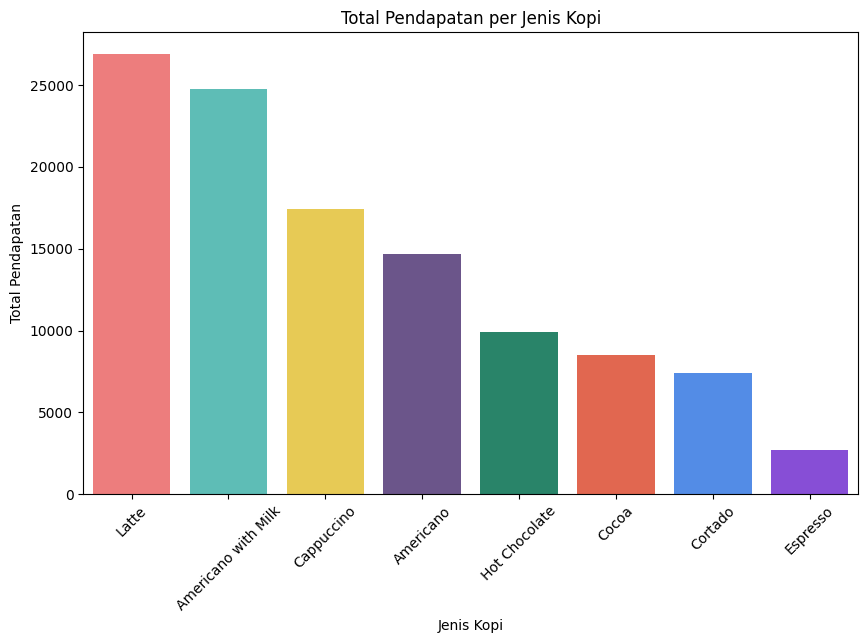

In [20]:
coffe_revenue = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=coffe_revenue.index, y=coffe_revenue.values,
            palette=['#FF6B6B', '#4ECDC4', '#FFD93D', '#6A4C93', '#1A936F', '#F95738', '#3A86FF', '#8338EC'],
            hue=coffe_revenue.index,
            legend=False)
plt.title('Total Pendapatan per Jenis Kopi')
plt.xlabel('Jenis Kopi')
plt.ylabel('Total Pendapatan')
plt.xticks(rotation=45)
plt.show()


**Insight:**

Berdasarkan grafik, Latte menghasilkan total pendapatan tertinggi dibandingkan jenis kopi lainnya, diikuti oleh Americano with Milk dan Cappuccino. Hal ini menunjukkan bahwa produk menggunakan susu lebih mendominasi kontribusi pendapatan. Sebaliknya, Espresso memiliki pendapatan terendah yang mengindikasikan tingkat permintaan yang lebih rendah dibandingkan produk lainnya.

## **Composition (Komposisi)**

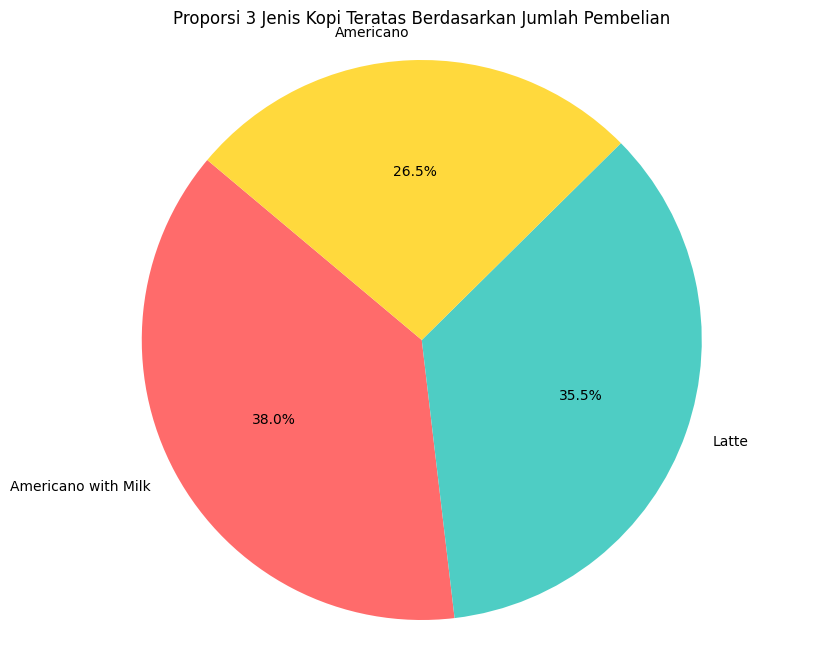

In [21]:
coffee_sales = df['coffee_name'].value_counts()
coffee_sales_top3 = coffee_sales.head(3)

colors = ['#FF6B6B', '#4ECDC4', '#FFD93D']

plt.figure(figsize=(10, 8))
coffee_sales_top3.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)

plt.title('Proporsi 3 Jenis Kopi Teratas Berdasarkan Jumlah Pembelian')
plt.ylabel('')
plt.axis('equal')
plt.show()

**Insight:**

Berdasarkan grafik, Americano with Milk merupakan jenis kopi yang paling banyak dibeli dengan proporsi sekitar 38%, diikuti oleh Latter sebesar 35.5% dan Americano sebesar 26.5%. Hal ini menunjukkan pelanggan cenderung lebih menyukai kopi dengan tambahan susu dibanding kopi hitam. Selain itu, perbedaan proporsi antar ketiga produk tidak terlalu jauh yang mengindikasikan ketiganya sama-sama memiliki tingkat permintaan yang tinggi.

## **Distribution (Distribusi)**

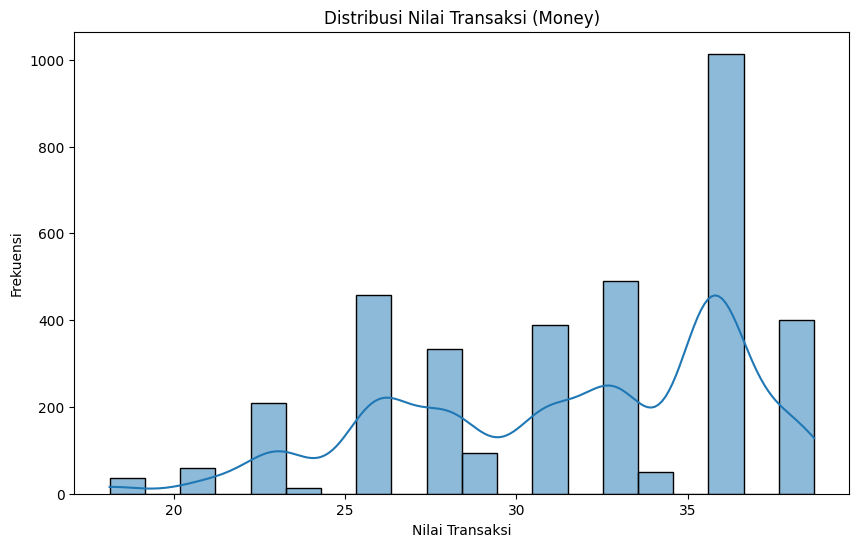

In [22]:
  plt.figure(figsize=(10, 6))
  sns.histplot(df['money'], bins=20, kde=True)

  plt.title('Distribusi Nilai Transaksi (Money)')
  plt.xlabel('Nilai Transaksi')
  plt.ylabel('Frekuensi')
  plt.show()

**Insight:**

Berdasarkan grafik distribusi, nilai transaksi paling banyak berada pada kisaran 30 sampai 36 yang menunjukkan sebagian besar pembelian memiliki harga di rentang tersebut. Distribusi data terlihat cukup terpusat tanpa adanya nilai ekstrem yang signifikan sehingga menunjukkan pola harga yang relatif stabil. Selain itu, frekuensi transaksi  pada nilai rendah maupun tinggi relatif lebih sedikit dibandingkan nilai tengah.

## **Relationship (Hubungan)**

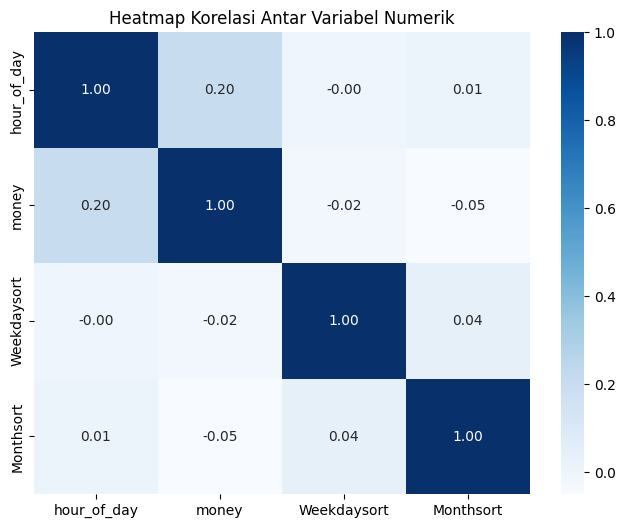

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['hour_of_day', 'money', 'Weekdaysort', 'Monthsort']].corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

**Insight:**

Berdasarkan heatmap, hubungan antar variabel numerik cenderung lemah. Variabel hour_of_day memiliki korelasi positif lemah dengan money (0.20) yang menunjukkan waktu transaksi hanya sedikit berpengaruh terhadap nilai transaksi. Sementara itu, variabel Weekdaysort dan Monthsort memiliki korelasi yang sangat rendah terhadap money sehingga hari dan bulan tidak memiliki pengaruh yang signifikan terhadap jumlah transaksi. Secara keseluruhan nilai transaksi lebih dipengaruhi oleh faktor lain di luar variabel waktu.